# CAIRLab Hackathon — Day 2 Extension: Intermediate + Advanced Tracks

Two new tracks unlock today, and you're free to attempt either or both between now and the
submission deadline:

| Track | Goal |
|---|---|
| 🟡 Intermediate | Client data is realistically **skewed** across the five banks — naive FedAvg performs worse under this skew. Fix the **aggregation**. |
| 🔴 Advanced (optional) | Partway through, one bank turns malicious and sends sabotaged updates. **Detect or resist** the attack. |

This notebook is self-contained — it rebuilds the dataset, partitions, model, and FL harness
from scratch, so you don't need yesterday's notebook open. The ideas carry over directly:
same story, same weak baseline, same FedAvg loop as Day 1, extended with what you need for
today's tracks.

**Scoring today:** unlike Day 1, these tracks aren't on a Kaggle leaderboard — a static
prediction file can't capture "how your aggregation holds up under skew" or "how much F1 your
defense recovers under attack." Instead, you'll report your before/after comparison in your
Kaggle Writeup, and export your final model for the organizers to spot-check. See the
Evaluation Rubric on the hackathon page for exact scoring weights.


> **Team Neuralynx — final submission notebook.** Organizer cells are unchanged except for a
> `reseed()` call before each run so that every before/after comparison starts from the same
> initial model and batch order. Our work is in the two `YOUR TURN` hooks and the cells marked
> *Neuralynx*. Primary track: 🔴 **Advanced** (Sentinel). Supporting: 🟡 Intermediate (FedNova-uniform).

## 0. Setup

In [1]:

# !pip -q install torch scikit-learn pandas numpy --upgrade 2>/dev/null
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import copy, json, os, hashlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
print("Setup complete.")


def reseed(s=SEED):
    """Reset every RNG so each run_fl call starts from the same initial model and
    the same mini-batch order. Before/after comparisons are therefore paired."""
    np.random.seed(s)
    torch.manual_seed(s)


Setup complete.


## 1. Load and clean the dataset (same as Day 1)


In [2]:

TRAIN_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
TEST_URL  = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"

COLS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty",
]

train_raw = pd.read_csv(TRAIN_URL, names=COLS)
test_raw  = pd.read_csv(TEST_URL, names=COLS)

def clean(df):
    df = df.drop(columns=["difficulty"]).copy()
    df["binary_label"] = (df["label"] != "normal").astype(int)
    return df

train_df = clean(train_raw)
test_df  = clean(test_raw)

CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}
for c in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[c], test_df[c]], axis=0))
    train_df[c] = le.transform(train_df[c])
    test_df[c]  = le.transform(test_df[c])
    encoders[c] = le

FEATURE_COLS = [c for c in train_df.columns if c not in ["label", "binary_label"]]

scaler = StandardScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("features:", len(FEATURE_COLS))


features: 41


## 2. Partition into 5 clients — IID (for reference) and non-IID (today's data)

Same holdout reservation logic as Day 1 (same seed, so it's the identical reserved rows —
this doesn't matter for today's scoring, it's just kept consistent).

Today you also get a **non-IID** partition: the same pool of training rows, but split so
each "bank" sees a skewed slice of traffic — one might see mostly denial-of-service attacks,
another almost entirely normal traffic. This is realistic (different banks see different
customers and attackers), and it's what breaks naive FedAvg.


In [3]:

N_CLIENTS = 5
HOLDOUT_SIZE = 15000

_rng = np.random.RandomState(SEED)
_perm = _rng.permutation(len(train_df))
_holdout_idx = _perm[:HOLDOUT_SIZE]
_pool_idx = _perm[HOLDOUT_SIZE:]
train_pool = train_df.iloc[_pool_idx].reset_index(drop=True)

def make_iid_partition(df, n_clients=N_CLIENTS, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df))
    chunks = np.array_split(idx, n_clients)
    return [df.iloc[c].reset_index(drop=True) for c in chunks]

FAMILY_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
}

def make_noniid_partition(df, n_clients=N_CLIENTS, alpha=0.3, seed=SEED):
    '''Dirichlet-skewed split by attack family. Low alpha = strong skew.'''
    rng = np.random.RandomState(seed)
    df = df.copy()
    df["family"] = df["label"].map(lambda x: FAMILY_MAP.get(x, "r2l_u2r_other"))
    client_indices = [[] for _ in range(n_clients)]
    for fam in df["family"].unique():
        fam_idx = df.index[df["family"] == fam].to_numpy().copy()
        rng.shuffle(fam_idx)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        split_points = (np.cumsum(proportions) * len(fam_idx)).astype(int)[:-1]
        for i, s in enumerate(np.split(fam_idx, split_points)):
            client_indices[i].extend(s.tolist())
    out = []
    for ci in client_indices:
        rng.shuffle(ci)
        out.append(df.loc[ci].drop(columns=["family"]).reset_index(drop=True))
    return out

iid_clients = make_iid_partition(train_pool)
noniid_clients = make_noniid_partition(train_pool)

print("IID sizes:", [len(c) for c in iid_clients])
print("\\nNon-IID sizes:", [len(c) for c in noniid_clients])
for i, c in enumerate(noniid_clients):
    print(f"  client {i} label mix:", c["binary_label"].value_counts(normalize=True).round(2).to_dict())


IID sizes: [22195, 22195, 22195, 22194, 22194]
\nNon-IID sizes: [6272, 10658, 48219, 23239, 22585]
  client 0 label mix: {1: 0.81, 0: 0.19}
  client 1 label mix: {1: 0.86, 0: 0.14}
  client 2 label mix: {1: 0.68, 0: 0.32}
  client 3 label mix: {0: 0.85, 1: 0.15}
  client 4 label mix: {0: 0.96, 1: 0.04}


## 3. The weak baseline model (same as Day 1)


In [4]:

N_FEATURES = len(FEATURE_COLS)

class WeakMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


## 4. The FL harness — extended with robust aggregation and attack simulation

Same local training and FedAvg as Day 1, plus what today's tracks need: a
`coordinate_median` robust-aggregation baseline, a `custom` aggregation hook, and the
ability to simulate malicious clients.


In [5]:

X_test = torch.tensor(test_df[FEATURE_COLS].values, dtype=torch.float32)
y_test = torch.tensor(test_df["binary_label"].values, dtype=torch.float32)

def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df["binary_label"].values, dtype=torch.float32)
    return X, y

def local_train(model, X, y, epochs=1, lr=0.05, batch_size=256):
    model = copy.deepcopy(model)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    n = len(X)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model

def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[i:i + n].view(p.shape))
        i += n

def fedavg(models, weights):
    weights = np.array(weights, dtype=float) / np.sum(weights)
    flats = torch.stack([get_flat_params(m) for m in models])
    avg = (flats * torch.tensor(weights, dtype=torch.float32).unsqueeze(1)).sum(dim=0)
    out = copy.deepcopy(models[0])
    set_flat_params(out, avg)
    return out

def coordinate_median(models):
    '''A simple robust-aggregation baseline: take the per-coordinate median of all
    client updates instead of the (weighted) mean. Outliers (e.g. a poisoned update
    with an inflated magnitude) influence the median far less than the mean.'''
    flats = torch.stack([get_flat_params(m) for m in models])
    med = flats.median(dim=0).values
    out = copy.deepcopy(models[0])
    set_flat_params(out, med)
    return out

def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_test)) > 0.5).float()
    return {
        "precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "f1": round(f1_score(y_test, preds, zero_division=0), 4),
    }

def run_fl(client_dfs, model_fn=lambda: WeakMLP(), rounds=8, epochs=1,
           aggregation="fedavg", agg_fn=None,
           malicious_clients=None, attack="scale", scale_factor=15.0, verbose=True):
    '''
    aggregation: "fedavg" | "median" | "custom" (use agg_fn for "custom")
    malicious_clients: list of client indices that send poisoned updates (advanced track)
    attack: "label_flip" or "scale" (scale = label_flip + inflated update magnitude)
    '''
    malicious_clients = malicious_clients or []
    global_model = model_fn()
    client_tensors = [df_to_tensors(df) for df in client_dfs]

    history = []
    for r in range(rounds):
        local_models, sizes = [], []
        global_flat = get_flat_params(global_model)

        for cid, (X, y) in enumerate(client_tensors):
            is_malicious = cid in malicious_clients
            if is_malicious:
                y = 1 - y  # label-flip
            lm = local_train(global_model, X, y, epochs=epochs)
            if is_malicious and attack == "scale":
                delta = get_flat_params(lm) - global_flat
                set_flat_params(lm, global_flat + scale_factor * delta)
            local_models.append(lm)
            sizes.append(len(X))

        prev_global_model = global_model
        if aggregation == "fedavg":
            global_model = fedavg(local_models, sizes)
        elif aggregation == "median":
            global_model = coordinate_median(local_models)
        elif aggregation == "custom":
            global_model = agg_fn(local_models, sizes, prev_global_model)
        else:
            raise ValueError(f"unknown aggregation: {aggregation}")

        metrics = evaluate(global_model)
        history.append(metrics)
        if verbose:
            print(f"round {r+1:>2}: {metrics}")

    return global_model, history


## 5. Recompute your Day 1 reference point

Quick reference run on IID data — same as your Day 1 baseline — so you have a same-session
number to compare today's non-IID results against.


In [6]:
reseed()

print("Reference: weak model, IID clients, naive FedAvg")
baseline_model, baseline_history = run_fl(iid_clients, rounds=6)
print("\\nFinal:", baseline_history[-1])


Reference: weak model, IID clients, naive FedAvg


round  1: {'precision': 0.9574, 'recall': 0.2875, 'f1': 0.4423}


round  2: {'precision': 0.9695, 'recall': 0.6026, 'f1': 0.7432}


round  3: {'precision': 0.9694, 'recall': 0.628, 'f1': 0.7622}


round  4: {'precision': 0.9315, 'recall': 0.6348, 'f1': 0.7551}


round  5: {'precision': 0.9324, 'recall': 0.6413, 'f1': 0.7599}


round  6: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}
\nFinal: {'precision': 0.9324, 'recall': 0.6473, 'f1': 0.7641}


---
## 🟡 Intermediate track — fix the non-IID aggregation

Switch to the skewed client split and watch what happens with plain FedAvg.


In [7]:
reseed()

print("Non-IID clients, naive FedAvg (same model, same aggregation as baseline)")
noniid_model, noniid_history = run_fl(noniid_clients, rounds=8)
print("\\nIID F1:    ", baseline_history[-1]["f1"])
print("Non-IID F1:", noniid_history[-1]["f1"])


Non-IID clients, naive FedAvg (same model, same aggregation as baseline)


round  1: {'precision': 0.9858, 'recall': 0.2063, 'f1': 0.3412}


round  2: {'precision': 0.9863, 'recall': 0.5166, 'f1': 0.678}


round  3: {'precision': 0.9436, 'recall': 0.5359, 'f1': 0.6836}


round  4: {'precision': 0.9374, 'recall': 0.5484, 'f1': 0.692}


round  5: {'precision': 0.9371, 'recall': 0.5554, 'f1': 0.6974}


round  6: {'precision': 0.9383, 'recall': 0.5625, 'f1': 0.7034}


round  7: {'precision': 0.9408, 'recall': 0.5662, 'f1': 0.7069}


round  8: {'precision': 0.9524, 'recall': 0.5681, 'f1': 0.7117}
\nIID F1:     0.7641
Non-IID F1: 0.7117


Naive FedAvg treats every client's update as equally trustworthy and just weights by
data size. When one client's local distribution is very different from the global
distribution (e.g. almost-all-attack-traffic), its update can pull the global model in a
direction that hurts everyone else.

**Ideas to improve aggregation**, roughly in order of effort:
- Weight clients differently — e.g. down-weight clients whose local class distribution is
  most different from the (estimated) global distribution.
- **FedProx-style**: add a proximal penalty term in local training that keeps each client's
  local model from drifting too far from the current global model.
- Cluster clients by similarity of their updates and aggregate within clusters before a
  final merge.

**Your hook:** write a function with signature
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass it to
`run_fl(..., aggregation="custom", agg_fn=my_agg_fn)`.


### Neuralynx approach — **FedNova with equal client weights**

**Diagnosis.** Look at the non-IID client sizes: `[6272, 10658, 48219, 23239, 22585]`. With
`batch_size=256` and one local epoch, the clients take **25, 42, 189, 91 and 89 local SGD
steps** respectively. Naive FedAvg then averages the resulting *models* weighted by data
size, so the update is dominated twice over by bank 2: it has the largest weight *and* it
drifted furthest (7.5x more steps than bank 0). Wang et al. (2020, *FedNova*) prove this
"objective inconsistency" makes FedAvg converge to the optimum of a **different, skewed
objective** — here one tilted towards bank 2 and the normal-heavy banks 3–4, which is why
recall collapses on the (57% attack) test set.

**Fix (two lines of maths, server-side only).**
1. Normalise each client's update by its number of local steps: `d_i = (w_i − w_global) / τ_i`.
   Every client now contributes an *average gradient direction*, not a drift length.
2. Combine with **equal client weights** `p_i = 1/K` and rescale by `τ_eff = Σ p_i τ_i`:
   `w_new = w_global + τ_eff · Σ p_i d_i`.

Equal weighting optimises the *average bank's* objective instead of the average *row's*:
each bank sees a different slice of the threat landscape (DoS-heavy, probe-heavy,
normal-heavy…), so no single slice should dominate the shared detector. No raw data, no
label counts, nothing beyond the update and its step count (a public function of batch
size) leaves a bank.

In [8]:
import math

def local_steps(n, batch_size=256, epochs=1):
    return epochs * math.ceil(n / batch_size)

def fednova_uniform_agg(local_models, sizes, prev_global_model):
    """FedNova (step-normalised) aggregation with equal per-client weights."""
    g = get_flat_params(prev_global_model)
    tau = np.array([local_steps(s) for s in sizes], dtype=float)
    p = np.ones(len(local_models)) / len(local_models)
    d = torch.stack([(get_flat_params(m) - g) / t for m, t in zip(local_models, tau)])
    step = (d * torch.tensor(p, dtype=torch.float32).unsqueeze(1)).sum(0) * float((p * tau).sum())
    out = copy.deepcopy(prev_global_model)
    set_flat_params(out, g + step)
    return out

my_agg_fn = fednova_uniform_agg
reseed()
custom_model, custom_history = run_fl(noniid_clients, rounds=8, aggregation="custom", agg_fn=my_agg_fn)
print("\nNaive non-IID F1:   ", noniid_history[-1]["f1"])
print("FedNova-uniform F1: ", custom_history[-1]["f1"])
print("Improvement:        ", round(custom_history[-1]["f1"] - noniid_history[-1]["f1"], 4))

round  1: {'precision': 0.9625, 'recall': 0.6655, 'f1': 0.7869}


round  2: {'precision': 0.925, 'recall': 0.6757, 'f1': 0.7809}


round  3: {'precision': 0.9234, 'recall': 0.6891, 'f1': 0.7892}


round  4: {'precision': 0.9217, 'recall': 0.686, 'f1': 0.7866}


round  5: {'precision': 0.9199, 'recall': 0.6836, 'f1': 0.7844}


round  6: {'precision': 0.9182, 'recall': 0.6823, 'f1': 0.7829}


round  7: {'precision': 0.9177, 'recall': 0.6823, 'f1': 0.7827}


round  8: {'precision': 0.9173, 'recall': 0.6816, 'f1': 0.7821}

Naive non-IID F1:    0.7117
FedNova-uniform F1:  0.7821
Improvement:         0.0704


#### Is it real? Ablation over 5 seeds

A single seed can flatter any method, so we rerun baseline, each ingredient alone, and the
combination on 5 seeds (paired: same seed ⇒ same init and batch order for every method).

In [9]:
SEEDS = [42, 0, 1, 2, 3]

def size_weighted_agg(local_models, sizes, prev):          # == FedAvg, via the hook
    return fedavg(local_models, sizes)

def uniform_avg_agg(local_models, sizes, prev):             # equal weights, no normalisation
    return fedavg(local_models, [1] * len(sizes))

def fednova_size_agg(local_models, sizes, prev):            # step-normalised, size weights
    g = get_flat_params(prev); tau = np.array([local_steps(s) for s in sizes], float)
    p = np.array(sizes, float); p /= p.sum()
    d = torch.stack([(get_flat_params(m) - g) / t for m, t in zip(local_models, tau)])
    out = copy.deepcopy(prev)
    set_flat_params(out, g + (d * torch.tensor(p, dtype=torch.float32).unsqueeze(1)).sum(0) * float((p * tau).sum()))
    return out

def multi_seed(make_kwargs, clients=None, seeds=SEEDS):
    res = []
    for s in seeds:
        reseed(s)
        _, h = run_fl(clients or noniid_clients, rounds=8, verbose=False, **make_kwargs())
        res.append(h[-1])
    return res

def summarise(res):
    f = [r["f1"] for r in res]
    return {"f1_mean": round(float(np.mean(f)), 4), "f1_std": round(float(np.std(f)), 4),
            "f1_min": round(float(np.min(f)), 4), "f1_max": round(float(np.max(f)), 4),
            "precision_mean": round(float(np.mean([r["precision"] for r in res])), 4),
            "recall_mean": round(float(np.mean([r["recall"] for r in res])), 4)}

ablation = {
    "Naive FedAvg (baseline)":        lambda: dict(aggregation="fedavg"),
    "Equal weights only":             lambda: dict(aggregation="custom", agg_fn=uniform_avg_agg),
    "FedNova (size weights) only":    lambda: dict(aggregation="custom", agg_fn=fednova_size_agg),
    "FedNova + equal weights (ours)": lambda: dict(aggregation="custom", agg_fn=fednova_uniform_agg),
    "Coordinate median":              lambda: dict(aggregation="median"),
}
inter_table = pd.DataFrame({k: summarise(multi_seed(v)) for k, v in ablation.items()}).T
inter_table

,f1_mean,f1_std,f1_min,f1_max,precision_mean,recall_mean
Naive FedAvg (baseline),0.7169,0.0057,0.7103,0.7241,0.9546,0.5741
Equal weights only,0.7536,0.0094,0.7420,0.7677,0.9295,0.6338
FedNova (size weights) only,0.7557,0.0111,0.7412,0.7699,0.9304,0.6364
FedNova + equal weights (ours),0.7809,0.0072,0.7681,0.7899,0.9190,0.6790
Coordinate median,0.7355,0.0148,0.7104,0.7514,0.9488,0.6008


---
## 🔴 Advanced track (optional) — detect or resist a poisoning attack

Partway through, imagine one of your five "banks" has been compromised (or is actively
malicious) and starts sending sabotaged updates instead of honest ones. Below, client `1`
is malicious: it flips its local labels **and** inflates the magnitude of its update so it
dominates a plain average, regardless of how much data it actually has.


In [10]:
reseed()

print("Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade")
attacked_model, attacked_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
)
print("\\nClean non-IID F1:  ", noniid_history[-1]["f1"])
print("Under attack F1:    ", attacked_history[-1]["f1"])


Non-IID + 1 malicious client (scale attack), naive FedAvg — should degrade


round  1: {'precision': 1.0, 'recall': 0.1038, 'f1': 0.1881}


round  2: {'precision': 0.9959, 'recall': 0.1128, 'f1': 0.2026}


round  3: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


round  4: {'precision': 0.8421, 'recall': 0.0087, 'f1': 0.0173}


round  5: {'precision': 0.8779, 'recall': 0.0118, 'f1': 0.0232}


round  6: {'precision': 0.854, 'recall': 0.0337, 'f1': 0.0649}


round  7: {'precision': 0.9868, 'recall': 0.2497, 'f1': 0.3986}


round  8: {'precision': 0.0794, 'recall': 0.0376, 'f1': 0.0511}
\nClean non-IID F1:   0.7117
Under attack F1:     0.0511


In [11]:
reseed()

print("Same attack, but aggregating with the coordinate-median baseline defense")
defended_model, defended_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="median",
)
print("\\nUnder attack (naive FedAvg): ", attacked_history[-1]["f1"])
print("Under attack (median defense):", defended_history[-1]["f1"])


Same attack, but aggregating with the coordinate-median baseline defense


round  1: {'precision': 1.0, 'recall': 0.082, 'f1': 0.1515}


round  2: {'precision': 0.999, 'recall': 0.1514, 'f1': 0.263}


round  3: {'precision': 0.9991, 'recall': 0.4551, 'f1': 0.6253}


round  4: {'precision': 0.9953, 'recall': 0.4952, 'f1': 0.6614}


round  5: {'precision': 0.9884, 'recall': 0.5102, 'f1': 0.673}


round  6: {'precision': 0.988, 'recall': 0.5186, 'f1': 0.6802}


round  7: {'precision': 0.9878, 'recall': 0.5227, 'f1': 0.6837}


round  8: {'precision': 0.9875, 'recall': 0.525, 'f1': 0.6855}
\nUnder attack (naive FedAvg):  0.0511
Under attack (median defense): 0.6855


`coordinate_median` is given as a working baseline defense — notice it already recovers
some of the lost F1. That's your floor, not your ceiling. Try cranking `scale_factor` up
(e.g. 30–50) and/or adding a second malicious client (`malicious_clients=[1, 3]`) — at some
point naive FedAvg collapses to F1 ≈ 0. Then push the defense further:

- **Trimmed mean** — drop the top/bottom k updates per coordinate before averaging.
- **Norm clipping** — clip each client's update to a maximum L2 norm before aggregating.
- **Anomaly scoring / Krum-style selection** — score each client's update by similarity to
  the others, and aggregate only the most mutually-consistent subset.
- **Detection, not just robustness** — can you flag *which* client(s) are malicious?

**Your hook:** same as the intermediate track — write
`agg_fn(local_models, sizes, prev_global_model) -> model` and pass `aggregation="custom"`.


### Neuralynx approach — **Sentinel**: detect → quarantine → clip → FedNova

**What we measured first.** We logged, per round, each client's step-normalised update
norm divided by the median norm (`ratio`). Clean honest banks never exceed **1.7×**. The
scale attacker sits at **19× in round 1 and keeps growing (>180× by round 8)**. So magnitude is a strong,
cheap signal here.

**What we deliberately did *not* use: cosine similarity to the consensus direction.**
Under non-IID data the honest attack-heavy banks 0 and 1 have a cosine of **−0.48** to the
median update in *clean* training — they legitimately push the other way from the
normal-heavy majority. A Krum/cosine filter would ban honest minority banks, i.e. the
defense itself would become a denial-of-service against under-represented traffic.

**Sentinel, per round:**
1. `d_i = (w_i − w_global) / τ_i` (FedNova normalisation — so a large bank is not "loud"
   just because it took more steps).
2. `ratio_i = ‖d_i‖ / median_j ‖d_j‖`. The median tolerates up to 2 of 5 attackers.
3. **Detect:** `ratio_i > 5` ⇒ excluded this round and receives a *strike*.
4. **Quarantine:** 2 strikes ⇒ excluded for the rest of training (reputation).
5. **Clip:** every surviving update is clipped to `2 × median` norm, bounding what any
   *undetected* client can do in one round.
6. Aggregate survivors with FedNova + equal weights (the intermediate-track fix).

**Why threshold 5 and not 3 (a failure we found).** With `T=3`, on the official seed the
defense started excluding *honest* bank 0 from round 4. Excluding a minority bank makes the
global model drift away from its traffic, so its next update is *even larger* (ratio grew
3 → 10) and it stays banned — a self-reinforcing false positive. With `T=5` plus clipping,
moderate outliers are *dampened, not banned*, and false exclusions dropped to zero.

In [12]:
def make_sentinel(T=5.0, clip=2.0, strikes_to_ban=2, log=None):
    """Returns a fresh, stateful Sentinel aggregator (it remembers strikes across rounds)."""
    strikes = {}
    def agg(local_models, sizes, prev_global_model):
        g = get_flat_params(prev_global_model); K = len(local_models)
        tau = np.array([local_steps(s) for s in sizes], dtype=float)
        d = torch.stack([(get_flat_params(m) - g) / t for m, t in zip(local_models, tau)])
        norms = d.norm(dim=1); med = norms.median()
        ratio = (norms / med).numpy()
        flagged = [i for i in range(K) if ratio[i] > T]
        for i in flagged:
            strikes[i] = strikes.get(i, 0) + 1
        keep = [i for i in range(K) if i not in flagged and strikes.get(i, 0) < strikes_to_ban]
        if not keep:                      # never aggregate an empty set
            keep = list(range(K))
        dk = d[keep] * torch.clamp(clip * med / norms[keep], max=1.0).unsqueeze(1)
        p = np.ones(len(keep)) / len(keep)
        step = (dk * torch.tensor(p, dtype=torch.float32).unsqueeze(1)).sum(0) * float((p * tau[keep]).sum())
        if log is not None:
            log.append({"ratio": [round(float(r), 2) for r in ratio], "flagged": flagged,
                        "quarantined": sorted(i for i, s in strikes.items() if s >= strikes_to_ban),
                        "aggregated": keep})
        out = copy.deepcopy(prev_global_model)
        set_flat_params(out, g + step)
        return out
    return agg

sentinel_log = []
my_defense_fn = make_sentinel(log=sentinel_log)
reseed()
my_defense_model, my_defense_history = run_fl(
    noniid_clients, rounds=8,
    malicious_clients=[1], attack="scale", scale_factor=15.0,
    aggregation="custom", agg_fn=my_defense_fn,
)
print("\nDetection log (client 1 is the attacker):")
for r, entry in enumerate(sentinel_log, 1):
    print(f"  round {r}: ratio={entry['ratio']}  flagged={entry['flagged']}  aggregated={entry['aggregated']}")
print("\nNaive under attack:    ", attacked_history[-1]["f1"])
print("Median defense:         ", defended_history[-1]["f1"])
print("Sentinel (ours):        ", my_defense_history[-1]["f1"])
print("F1 recovered:           ", round(my_defense_history[-1]["f1"] - attacked_history[-1]["f1"], 4))

round  1: {'precision': 0.9548, 'recall': 0.2552, 'f1': 0.4028}


round  2: {'precision': 0.9687, 'recall': 0.6169, 'f1': 0.7538}


round  3: {'precision': 0.969, 'recall': 0.6328, 'f1': 0.7656}


round  4: {'precision': 0.9696, 'recall': 0.6381, 'f1': 0.7697}


round  5: {'precision': 0.9302, 'recall': 0.6436, 'f1': 0.7608}


round  6: {'precision': 0.928, 'recall': 0.6426, 'f1': 0.7593}


round  7: {'precision': 0.9278, 'recall': 0.6441, 'f1': 0.7604}


round  8: {'precision': 0.9295, 'recall': 0.637, 'f1': 0.756}

Detection log (client 1 is the attacker):
  round 1: ratio=[1.68, 18.89, 0.68, 1.0, 0.96]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 2: ratio=[2.43, 38.53, 0.68, 1.0, 0.98]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 3: ratio=[2.95, 75.32, 0.68, 1.0, 0.97]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 4: ratio=[3.05, 109.34, 0.63, 0.99, 1.0]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 5: ratio=[3.06, 124.19, 0.58, 1.0, 0.94]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 6: ratio=[3.55, 143.97, 0.61, 0.97, 1.0]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 7: ratio=[3.79, 157.08, 0.61, 1.0, 0.96]  flagged=[1]  aggregated=[0, 2, 3, 4]
  round 8: ratio=[4.23, 181.42, 0.66, 1.0, 1.0]  flagged=[1]  aggregated=[0, 2, 3, 4]

Naive under attack:     0.0511
Median defense:          0.6855
Sentinel (ours):         0.756
F1 recovered:            0.7049


#### Stress test — stronger, weaker, colluding and stealthier attackers (5 seeds each)

A defense tuned to one attack is not a defense. We rerun every aggregator on six scenarios
and count detections per client-round (5 seeds × 8 rounds = 40 client-rounds per attacker).

In [13]:
scenarios = {
    "No attack":                    (dict(), []),
    "Scale x15, client 1 (official)": (dict(malicious_clients=[1], attack="scale", scale_factor=15.0), [1]),
    "Scale x50, client 1":          (dict(malicious_clients=[1], attack="scale", scale_factor=50.0), [1]),
    "Scale x3, client 1 (stealthy)": (dict(malicious_clients=[1], attack="scale", scale_factor=3.0), [1]),
    "Scale x15, clients 1+3":       (dict(malicious_clients=[1, 3], attack="scale", scale_factor=15.0), [1, 3]),
    "Label-flip only, client 1":    (dict(malicious_clients=[1], attack="label_flip"), [1]),
}
defenses = {
    "FedAvg":            lambda log: dict(aggregation="fedavg"),
    "Coord. median":     lambda log: dict(aggregation="median"),
    "Norm-clip (skeleton)": None,   # filled below
    "Sentinel (ours)":   lambda log: dict(aggregation="custom", agg_fn=make_sentinel(log=log)),
}

def clip_skeleton(local_models, sizes, prev_global_model):   # the notebook's example defense
    ref = get_flat_params(prev_global_model); fl = []
    for m in local_models:
        dd = get_flat_params(m) - ref; n = dd.norm()
        fl.append(ref + (dd * (5.0 / n) if n > 5.0 else dd))
    w = np.array(sizes, float); w /= w.sum()
    out = copy.deepcopy(local_models[0])
    set_flat_params(out, (torch.stack(fl) * torch.tensor(w, dtype=torch.float32).unsqueeze(1)).sum(0))
    return out
defenses["Norm-clip (skeleton)"] = lambda log: dict(aggregation="custom", agg_fn=clip_skeleton)

rows, det_rows = [], []
for sname, (skw, bad) in scenarios.items():
    for dname, make in defenses.items():
        f, caught, false_excl = [], 0, 0
        for s in SEEDS:
            log = []
            reseed(s)
            _, h = run_fl(noniid_clients, rounds=8, verbose=False, **make(log), **skw)
            f.append(h[-1]["f1"])
            for e in log:
                excluded = set(range(N_CLIENTS)) - set(e["aggregated"])
                caught += len(excluded & set(bad)); false_excl += len(excluded - set(bad))
        rows.append({"scenario": sname, "defense": dname, "f1_mean": round(float(np.mean(f)), 4),
                     "f1_min": round(float(np.min(f)), 4)})
        if dname == "Sentinel (ours)":
            det_rows.append({"scenario": sname,
                             "attacker client-rounds excluded": f"{caught}/{40 * len(bad)}" if bad else "n/a",
                             "honest client-rounds excluded": false_excl})
stress = pd.DataFrame(rows).pivot(index="scenario", columns="defense", values="f1_mean")[list(defenses)]
stress = stress.loc[list(scenarios)]
display(stress)
display(pd.DataFrame(det_rows).set_index("scenario"))

defense,FedAvg,Coord. median,Norm-clip (skeleton),Sentinel (ours)
scenario,,,,
No attack,0.7169,0.7355,0.7169,0.7809
"Scale x15, client 1 (official)",0.2194,0.6793,0.6188,0.7599
"Scale x50, client 1",0.5210,0.6794,0.6188,0.7599
"Scale x3, client 1 (stealthy)",0.6583,0.6768,0.6583,0.7555
"Scale x15, clients 1+3",0.1381,0.7348,0.4809,0.7762
"Label-flip only, client 1",0.6875,0.6747,0.6875,0.7523


,attacker client-rounds excluded,honest client-rounds excluded
scenario,,
No attack,n/a,0
"Scale x15, client 1 (official)",40/40,0
"Scale x50, client 1",40/40,0
"Scale x3, client 1 (stealthy)",34/40,0
"Scale x15, clients 1+3",80/80,0
"Label-flip only, client 1",15/40,0


## 7. Results chart (used as the Writeup cover image)

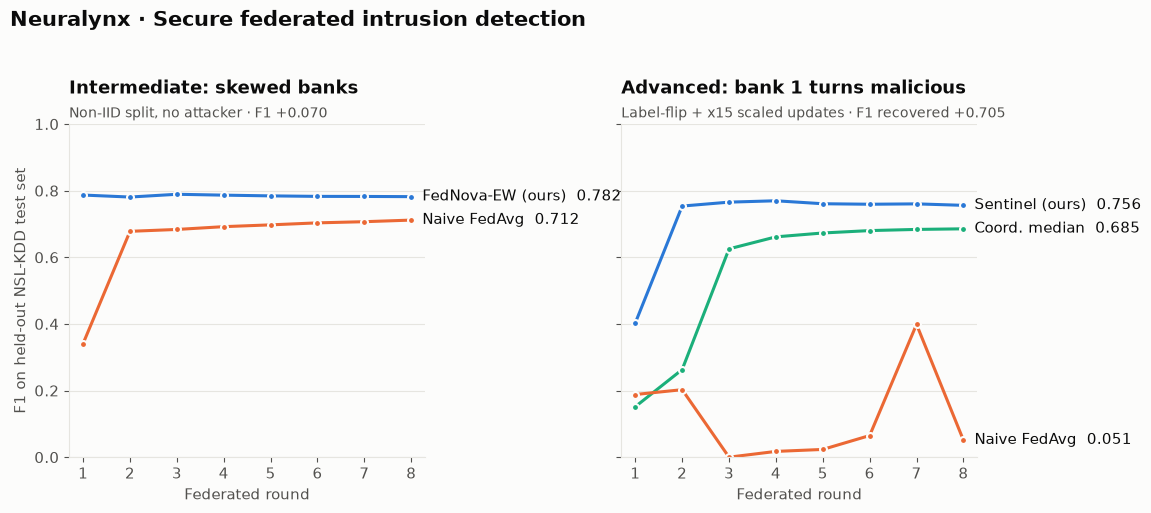

In [14]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e0"
OURS, NAIVE, MEDIAN = "#2a78d6", "#eb6834", "#1baf7a"   # fixed categorical slots 1-3

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True, facecolor=SURFACE)
rounds = np.arange(1, 9)

def panel(ax, series, title, subtitle):
    ax.set_facecolor(SURFACE)
    for label, hist, color in series:
        f = [h["f1"] for h in hist]
        ax.plot(rounds, f, color=color, lw=2.2, marker="o", ms=5,
                markeredgecolor=SURFACE, markeredgewidth=1.5)
        ax.annotate(f"{label}  {f[-1]:.3f}", (8, f[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK, fontsize=10.5)
    ax.set_title(title, loc="left", color=INK, fontsize=13, fontweight="bold", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTED, fontsize=10)
    ax.set_xticks(rounds); ax.set_xlabel("Federated round", color=MUTED)
    ax.set_ylim(0, 1); ax.set_xlim(0.7, 8.3)
    ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color(GRID)
    ax.tick_params(colors=MUTED)

panel(axes[0], [("FedNova-EW (ours)", custom_history, OURS),
                ("Naive FedAvg", noniid_history, NAIVE)],
      "Intermediate: skewed banks", f"Non-IID split, no attacker · F1 +{custom_history[-1]['f1'] - noniid_history[-1]['f1']:.3f}")
panel(axes[1], [("Sentinel (ours)", my_defense_history, OURS),
                ("Coord. median", defended_history, MEDIAN),
                ("Naive FedAvg", attacked_history, NAIVE)],
      "Advanced: bank 1 turns malicious", f"Label-flip + x15 scaled updates · F1 recovered +{my_defense_history[-1]['f1'] - attacked_history[-1]['f1']:.3f}")
axes[0].set_ylabel("F1 on held-out NSL-KDD test set", color=MUTED)
fig.suptitle("Neuralynx · Secure federated intrusion detection", x=0.01, ha="left",
             color=INK, fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 0.89, 0.95))
plt.subplots_adjust(wspace=0.55)
fig.savefig("f1_over_rounds.png", dpi=200, facecolor=SURFACE)
plt.show()

---
## 8. Submission (rubric-graded, no Kaggle leaderboard)

Run this to export your final model. Pick whichever result (intermediate aggregation or
advanced defense) you want judged — set `TRACK` and `FINAL_MODEL` accordingly.

**Input contract:** your exported model's `forward(x)` must accept the standard 41-column
preprocessed feature tensor exactly as produced in Section 1 (`FEATURE_COLS`, same order,
same scaling). If you did feature engineering, build it as extra layers *inside* your model
rather than as a separate preprocessing step.


In [15]:
TEAM_NAME = "Neuralynx"
TRACK = "advanced"  # primary track: Sentinel. Intermediate result reported as supporting work.
FINAL_MODEL = my_defense_model  # Sentinel under the official attack (client 1, scale x15)

final_metrics = evaluate(FINAL_MODEL)

FINAL_MODEL.eval()
scripted = torch.jit.script(FINAL_MODEL)
scripted.save("model_scripted.pt")

submission = {
    "team_name": TEAM_NAME,
    "track": TRACK,
    "self_reported_metrics": final_metrics,
    "model_file": "model_scripted.pt",
    "n_input_features": N_FEATURES,
}
with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

# Supporting artefacts (not part of the organizers' schema): intermediate model + all numbers
custom_model.eval()
torch.jit.script(custom_model).save("model_intermediate_scripted.pt")
results = {
    "intermediate": {"before_naive_fedavg": noniid_history[-1], "after_fednova_uniform": custom_history[-1],
                     "f1_improvement": round(custom_history[-1]["f1"] - noniid_history[-1]["f1"], 4),
                     "five_seed_ablation": inter_table.to_dict(orient="index")},
    "advanced": {"before_fedavg_under_attack": attacked_history[-1], "median_defense": defended_history[-1],
                 "after_sentinel": my_defense_history[-1],
                 "f1_recovered": round(my_defense_history[-1]["f1"] - attacked_history[-1]["f1"], 4),
                 "stress_test_f1_mean_5_seeds": stress.to_dict(orient="index"),
                 "sentinel_detection_log_official_run": sentinel_log},
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

# Sanity check: the exported TorchScript file reproduces the reported metrics
reloaded = torch.jit.load("model_scripted.pt")
with torch.no_grad():
    preds = (torch.sigmoid(reloaded(X_test)) > 0.5).float()
print("Reloaded model F1:", round(f1_score(y_test, preds), 4))
print(json.dumps(submission, indent=2))

Reloaded model F1: 0.756
{
  "team_name": "Neuralynx",
  "track": "advanced",
  "self_reported_metrics": {
    "precision": 0.9295,
    "recall": 0.637,
    "f1": 0.756
  },
  "model_file": "model_scripted.pt",
  "n_input_features": 41
}


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\torch\jit\_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


### What to hand in
1. Your Kaggle Writeup — include the before/after F1 comparison for whichever track(s) you
   attempted, this is your primary evidence for the Automated Detection Score.
2. Your GitHub repo (Project Link) containing `model_scripted.pt`, `submission.json`, and
   this notebook, fully run.
3. Cover image, video (≤3 min), all per the Submission Requirements.
4. Be ready to demo live on Day 7.
